In [1]:
import xarray as xr

In [2]:
df_uo = xr.open_dataset("../data/raw/adriatic_currents_uo_detided_2023_2024.nc")
df_vo = xr.open_dataset("../data/raw/adriatic_currents_vo_detided_2023_2024.nc")


In [3]:
# df_uo = df_uo.dropna(dim='time', how='any')
# df_vo = df_vo.dropna(dim='time', how='any')


In [4]:
mean_vo_w_czasie = df_uo['uo_detided'].mean(dim=['latitude', 'longitude'])
mean_uo_w_czasie = df_vo['vo_detided'].mean(dim=['latitude', 'longitude'])

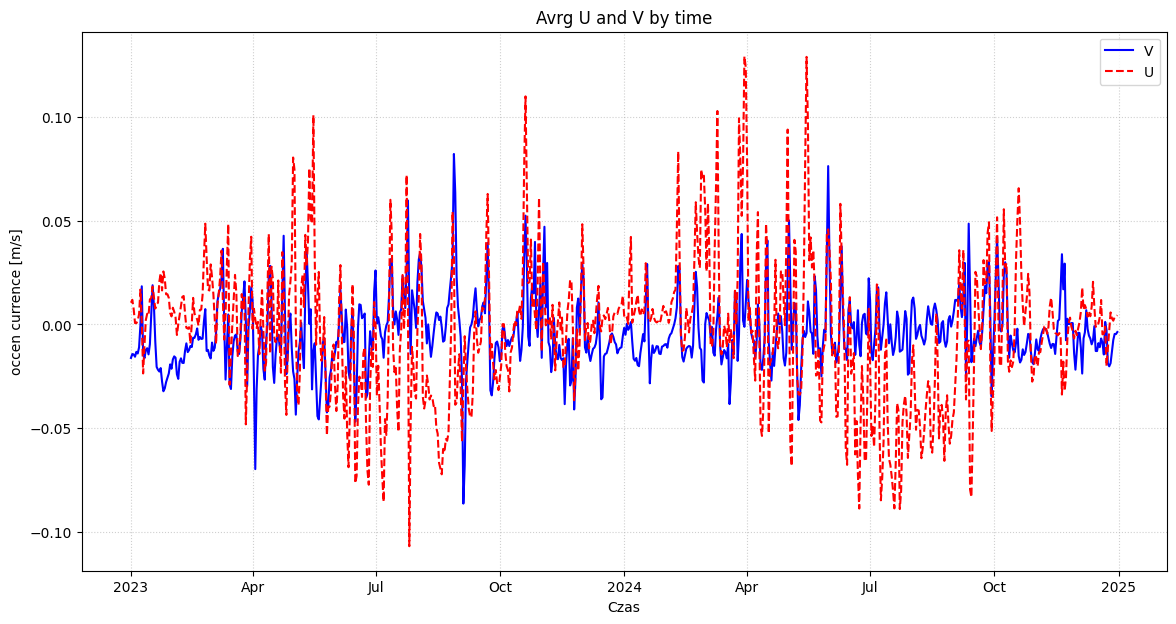

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

mean_vo_w_czasie.plot(
    label='V',
    color='blue',
    linewidth=1.5
)

mean_uo_w_czasie.plot(
    label='U',
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.title('Avrg U and V by time')
plt.xlabel('Czas')
plt.ylabel('occen currence [m/s]')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [6]:
df_uo = df_uo[['longitude', 'latitude', 'uo_detided']].to_dataframe()
df_vo = df_vo[['longitude', 'latitude', 'vo_detided']].to_dataframe()


In [7]:
df_uo = df_uo[df_uo['uo_detided'].notna()]
df_vo = df_vo[df_vo['vo_detided'].notna()]


In [8]:
import numpy as np

target_lat = 42.864690
target_lon = 17.694627

# get unique grid coordinates
coords = df_vo.index.droplevel("time").unique()

# convert to array for distance calc
lons = coords.get_level_values("longitude").to_numpy()
lats = coords.get_level_values("latitude").to_numpy()

dist = (lats - target_lat)**2 + (lons - target_lon)**2
i = dist.argmin()

nearest_lon = lons[i]
nearest_lat = lats[i]

print("Nearest grid point:", nearest_lat, nearest_lon)


Nearest grid point: 42.8125 17.666666


In [9]:
nearest_point_vo = df_vo.loc[(nearest_lon, nearest_lat)]
nearest_point_uo = df_uo.loc[(nearest_lon, nearest_lat)]

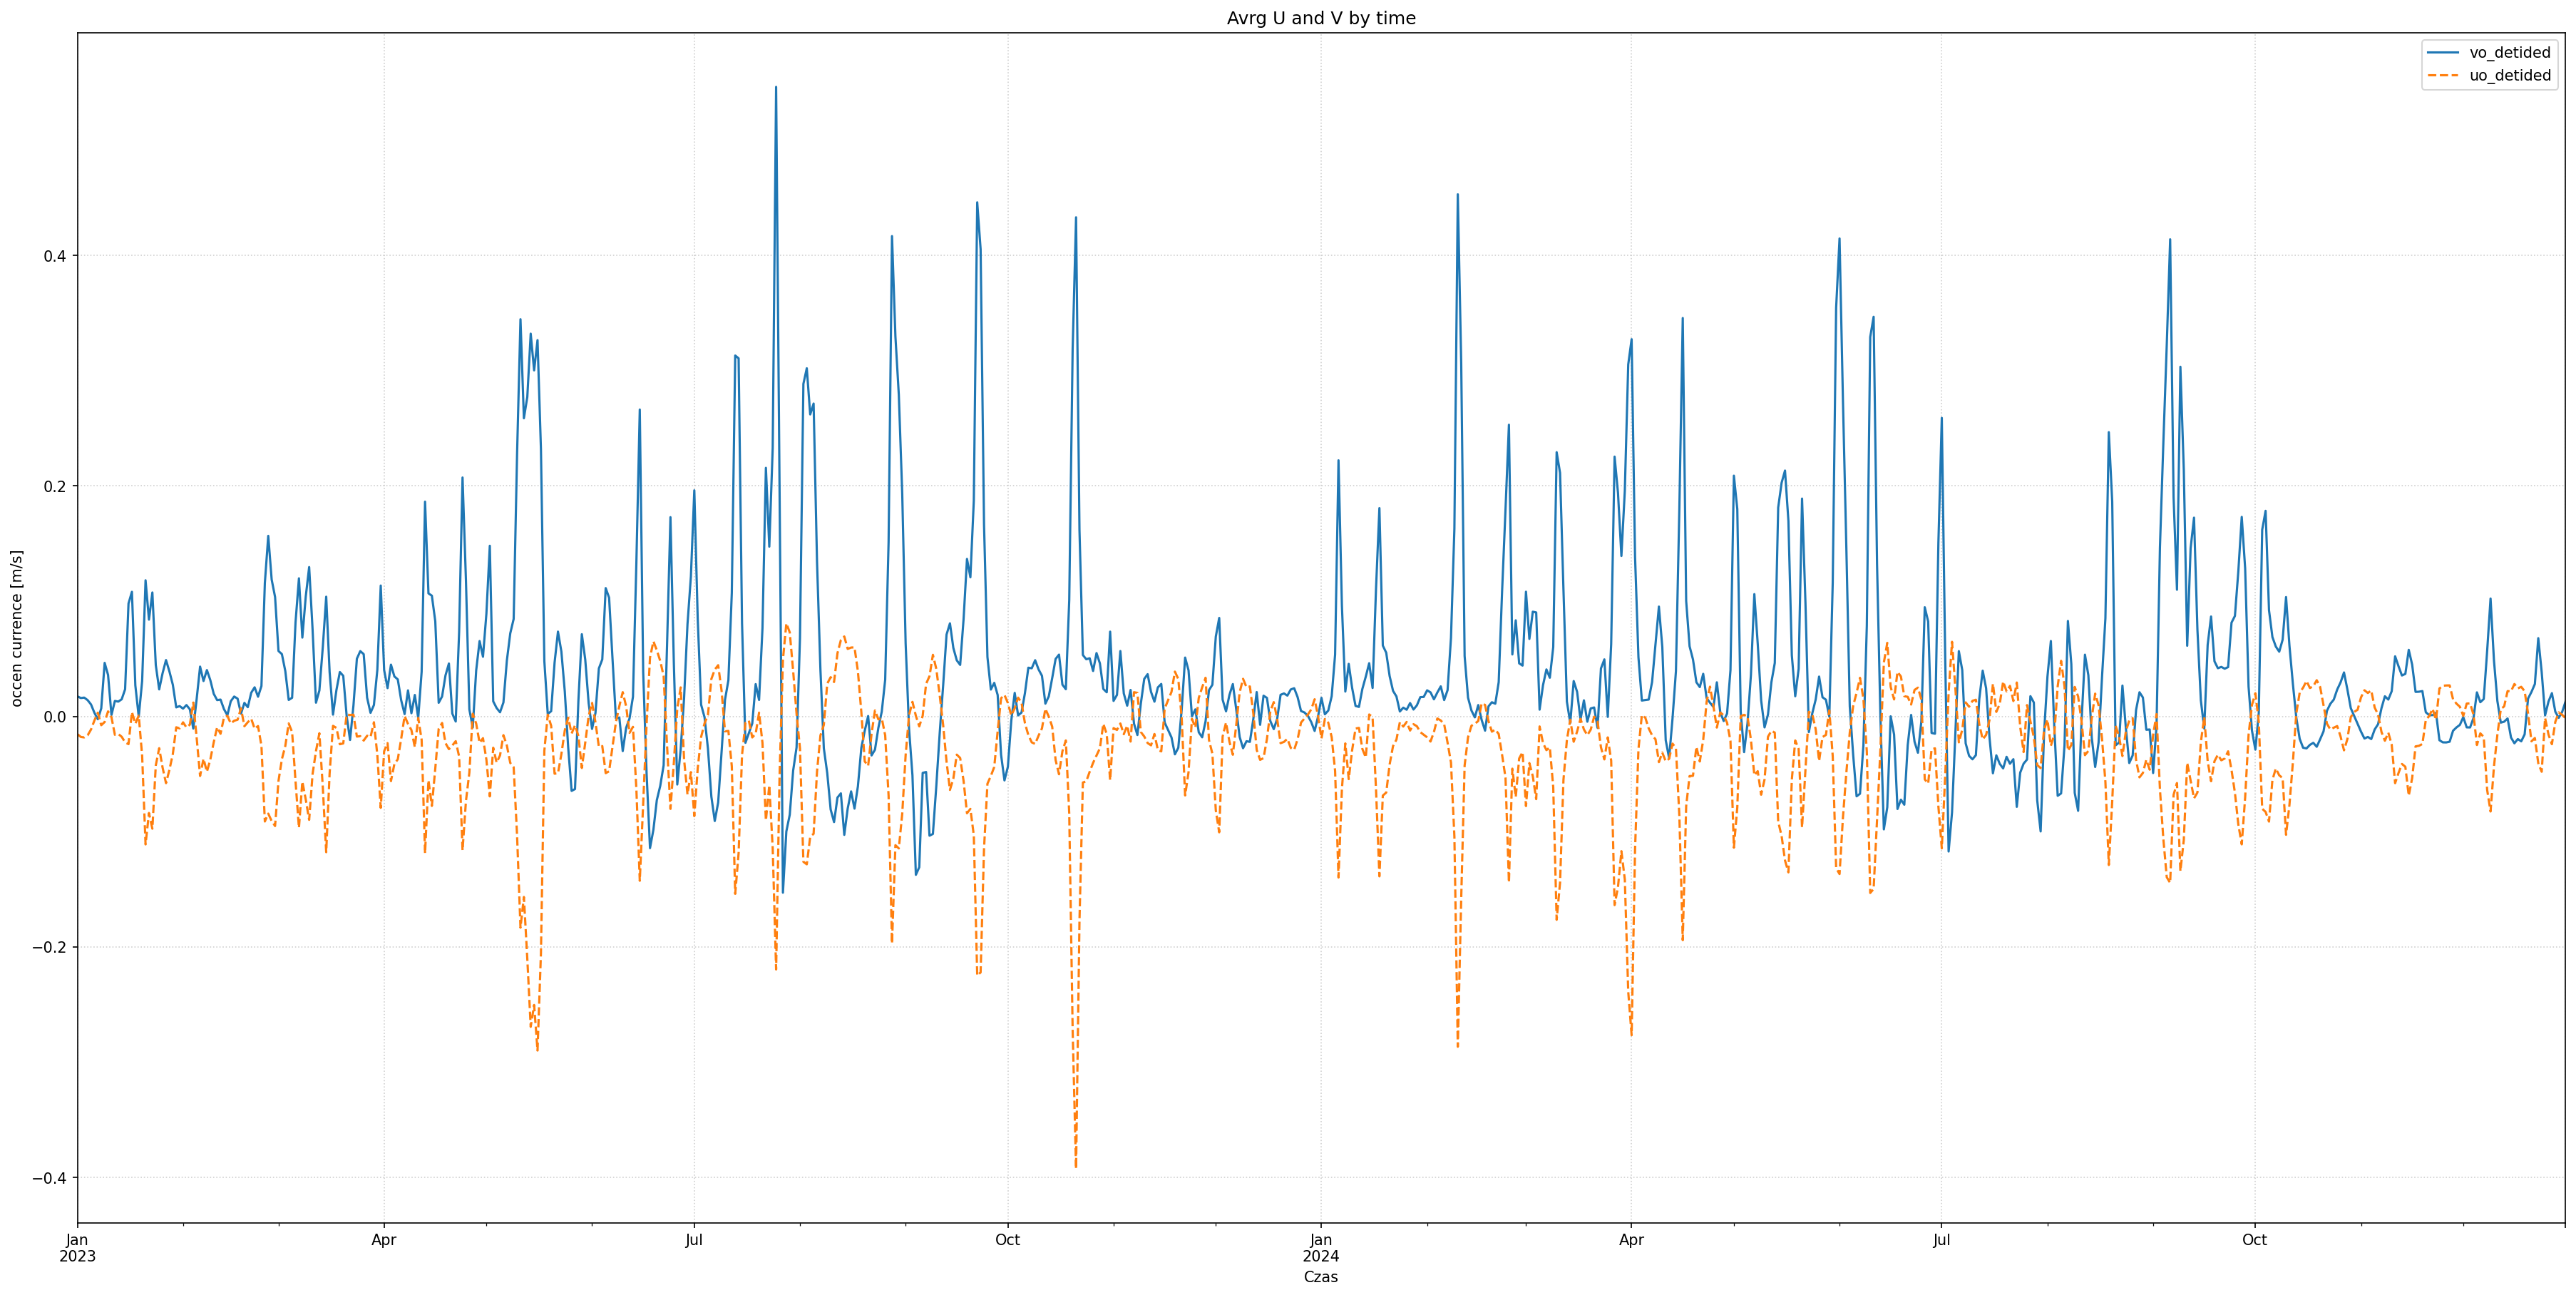

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)

nearest_point_vo.plot(ax=ax, label='V', linewidth=1.5)
nearest_point_uo.plot(ax=ax, label='U', linestyle='--', linewidth=1.5)

plt.tight_layout()

plt.title('Avrg U and V by time')
plt.xlabel('Czas')
plt.ylabel('occen currence [m/s]')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

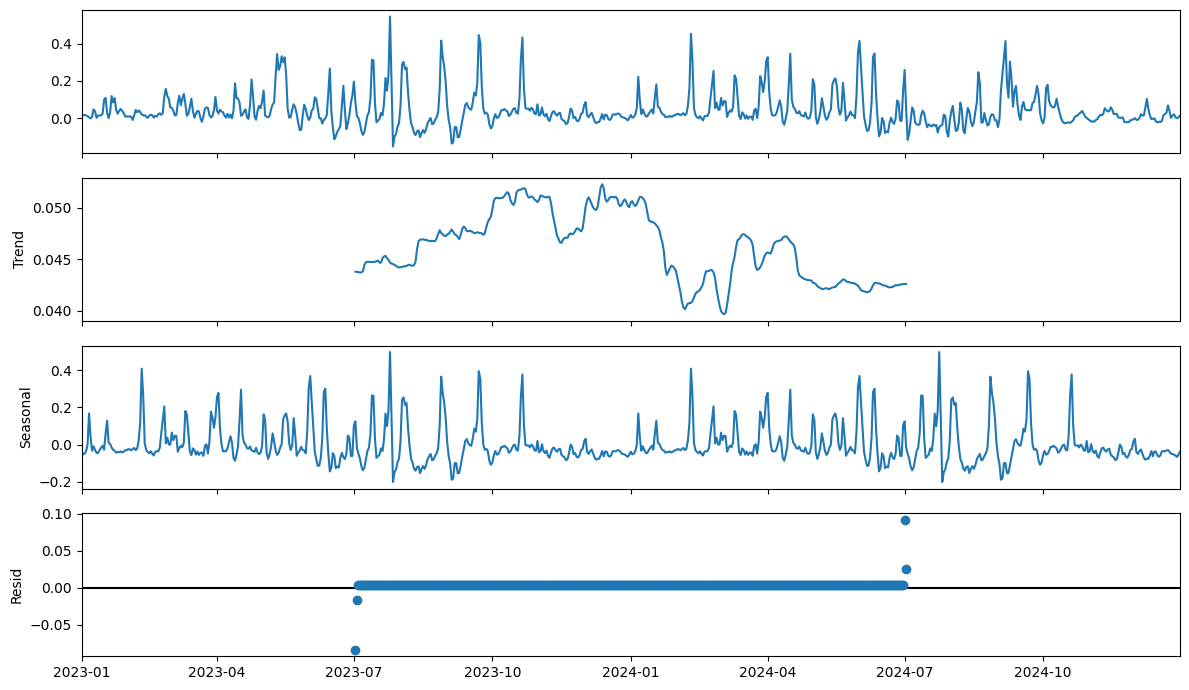

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = nearest_point_vo.copy()
series = series.asfreq("D")   # enforce daily frequency

result = seasonal_decompose(series, model="additive", period=365)

fig = result.plot()
fig.set_size_inches(12, 7)   # <<< THIS controls the real size
plt.tight_layout()
plt.show()


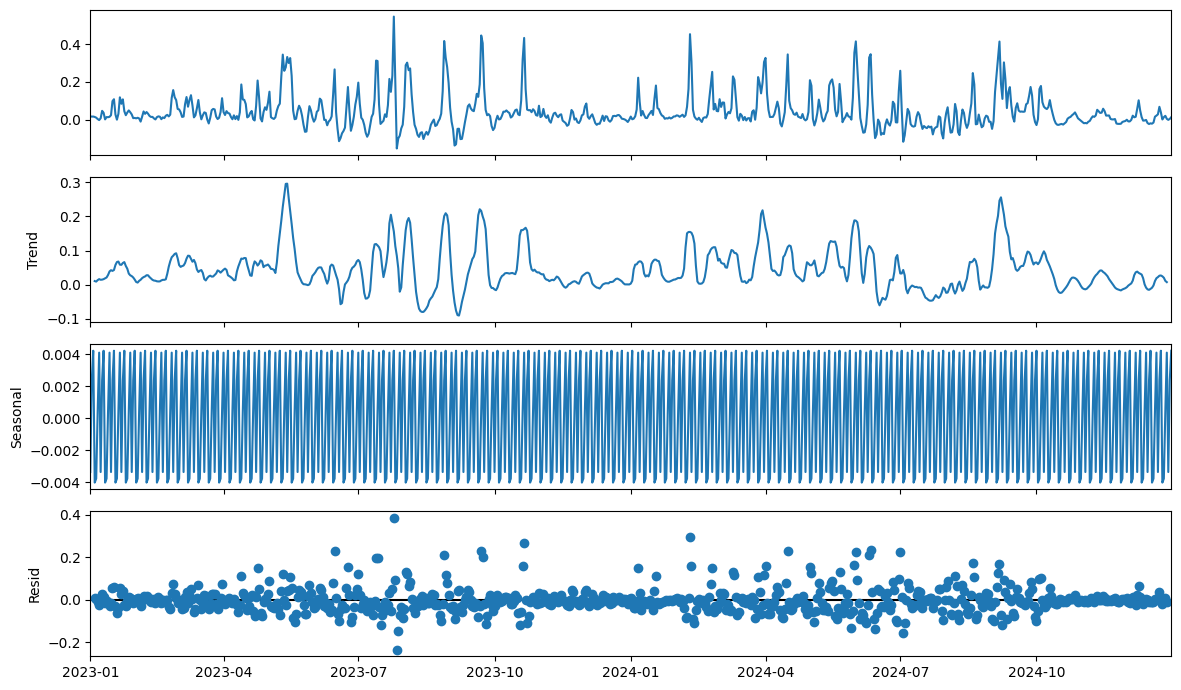

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = nearest_point_vo.copy()
series = series.asfreq("D")   # enforce daily frequency

result = seasonal_decompose(series, model="additive", period=7)

fig = result.plot()
fig.set_size_inches(12, 7)   # <<< THIS controls the real size
plt.tight_layout()
plt.show()


- Trend – a long-term tendency (i.e., whether ocean speed is increasing, decreasing, or stable over the years).

- Seasonality – a recurring cycle, e.g., the annual cycle of ocean currents. period=365 means that the program looks at a full year, because the data is daily.

- Residual – everything that remains after subtracting the trend and seasonality, i.e., noise, anomalies, random fluctuations.

### Key Takeaways
- Periodicity: period=365 is effective; the annual seasonality is well-defined over the two-year span.

- Dominant Factors: Seasonal cycles are the primary driver of velocity changes, as the trend is minimal.

- Model Fit: Low residuals suggest a high-quality decomposition with very little noise.

In [13]:
from statsmodels.tsa.stattools import adfuller

series = nearest_point_vo.copy()
adf_result = adfuller(series.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))


ADF Statistic: -10.16559915172657
p-value: 7.313227165317595e-18
Critical Value (1%): -3.439
Critical Value (5%): -2.866
Critical Value (10%): -2.569


ADF statistic close to 0 and high p-value → non-stationary series

Low p-value (< 0.05) → we reject the hypothesis of non-stationarity → stationary series

Interpretation:
- The ADF statistic is much smaller than all critical values → we strongly reject the null hypothesis of non-stationarity.
- The very low p-value confirms that the series is stationary.

In short: the time series is stationary, and you can immediately use it for ARIMA, SARIMA, or other methods that require stationarity.

<Figure size 1200x600 with 0 Axes>

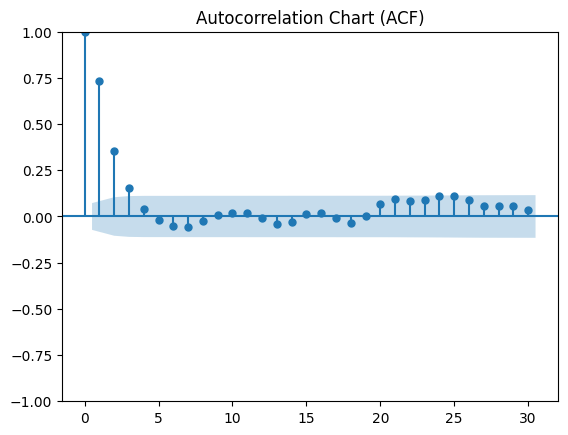

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_to_plot = series.dropna()  # usuwa NaN, jeśli są
plt.figure(figsize=(12, 6))
plot_acf(data_to_plot, lags=30)
plt.title("Autocorrelation Chart (ACF)")
plt.show()




### ACF Analysis & ARIMA Configuration

**ACF Plot Observations**

- Lag 1: Strong positive correlation (~0.73).

- Lags 2 & 3: Significant positive correlation (~0.35 and ~0.15) before declining.

- Seasonality: No distinct periodic spikes (e.g., at lag 7), indicating weak seasonality.

**ARIMA Interpretation**

- MA (q): The ACF decay after 2–3 lags suggests a parameter of q = 2 or q = 3.

- AR (p): Requires PACF analysis; the 'p' value is determined by the lag where PACF cuts off.

- Recommendation: Start with a standard ARIMA(p, d, 2) model given the lack of strong seasonal indicators in the ACF.

<Figure size 1200x600 with 0 Axes>

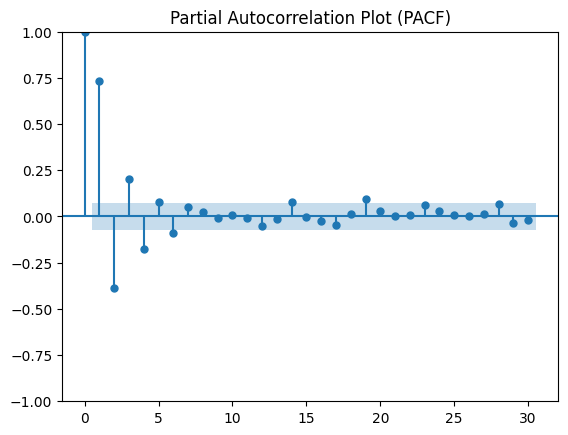

In [14]:
plt.figure(figsize=(12, 6))
plot_pacf(data_to_plot, lags=30, method='ywm')  # metoda 'ywm' jest stabilna
plt.title("Partial Autocorrelation Plot (PACF)")
plt.show()


In [19]:
from itertools import product
import statsmodels.api as sm
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

y = nearest_point_vo.values.flatten()

# -------------------------------------
# 2. Train/test split
# -------------------------------------
test_size = int(len(y) * 0.2)    # last 20% as rolling test
train_data = y[:-test_size]
test = y[-test_size:]

# Parametry do przetestowania
p_vals = range(0, 3)
d_vals = range(0, 1)
q_vals = range(0, 3)

best_mae = float('inf')
best_r2 = float('inf')

best_order = None

for p, d, q in product(p_vals, d_vals, q_vals):
    try:
        predictions = []
        for i in range(len(test)):
            train_data = y[:test_size + i]
            model = ARIMA(train_data, order=(p, d, q))
            fitted = model.fit()
            pred = fitted.forecast(steps=1)[0]
            predictions.append(pred)
        
        mae = np.mean(np.abs(test - np.array(predictions)))
        r2 = r2_score(test, predictions)
        
        if r2 < best_r2:
            best_mae = mae
            best_r2 = r2
            best_order = (p, d, q)
            print(f"New best: {best_order}, MAE: {mae:.4f}")
    except:
        continue

print(f"\nBest order: {best_order}, MAE: {best_mae:.4f}, r2: {r2}")

/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

New best: (0, 0, 0), MAE: 0.0566


/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


New best: (0, 0, 1), MAE: 0.0699


/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

New best: (1, 0, 1), MAE: 0.0802


/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('N

New best: (2, 0, 2), MAE: 0.0811

Best order: (2, 0, 2), MAE: 0.0811, r2: -1.4248504638671875


/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
from pmdarima import auto_arima

auto_model = auto_arima(train_data, seasonal=False, trace=True)
print(auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-804.739, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-452.420, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-747.842, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-710.472, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-806.737, Time=0.10 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-778.409, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-807.639, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-806.674, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-781.201, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-818.858, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-751.378, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-753.513, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-816.951, Time=0.17 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-816.942, Time=0.30 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept


Results Table:
   Model    Order       MAE        R2
0  ARIMA  (0,1,2)  0.026926  0.655892


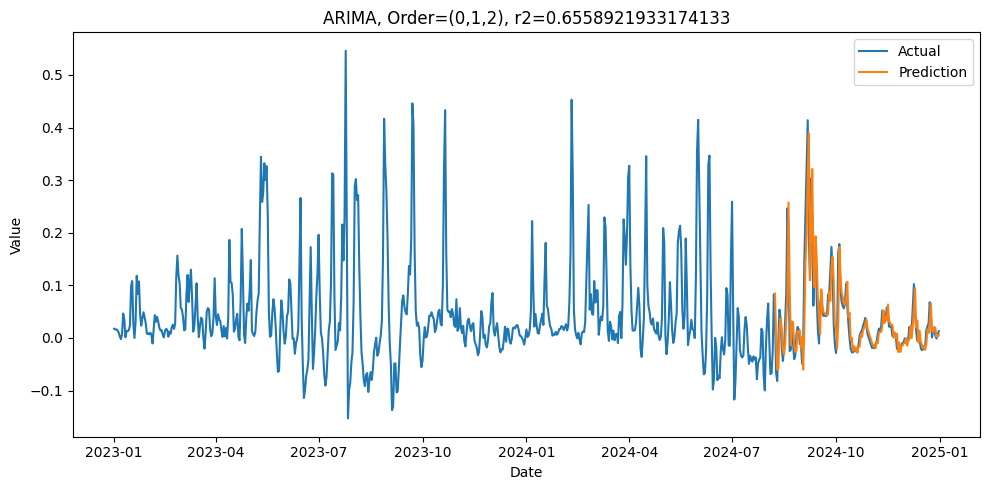

In [26]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

y = nearest_point_vo.values.flatten()

# -------------------------------------
# Train/test split
# -------------------------------------
test_size = int(len(y) * 0.2)
train = y[:-test_size]
test = y[-test_size:]

predictions = []

# rolling forecast
for i in range(test_size):
    train_data = y[: len(y) - test_size + i]   # expanding window
    model = ARIMA(train_data, order=(0, 1, 2))
    fitted = model.fit()
    pred = fitted.forecast()[0]
    predictions.append(pred)

# metrics
mae = mean_absolute_error(test, predictions)
r2 = r2_score(test, predictions)

# Table
results_table = pd.DataFrame({
    "Model": ["ARIMA"],
    "Order": ["(0,1,2)"],
    "MAE": [mae],
    "R2": [r2]
})

print("\nResults Table:")
print(results_table)

# index for predictions
pred_index = nearest_point_vo.index[-test_size:]

preds_ser = pd.Series(predictions, index=pred_index)

plt.figure(figsize=(10,5))
plt.plot(nearest_point_vo.index, nearest_point_vo.values, label="Actual")
plt.plot(preds_ser.index, preds_ser.values, label="Prediction")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"ARIMA, Order=(0,1,2), r2={r2}")
plt.legend()
plt.tight_layout()
plt.show()


/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/igor-czudy/miniconda3/envs/onblue_3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Results Table:
   Model      Order       MAE        R2
0  ARIMA  (1, 0, 1)  0.027541  0.675687


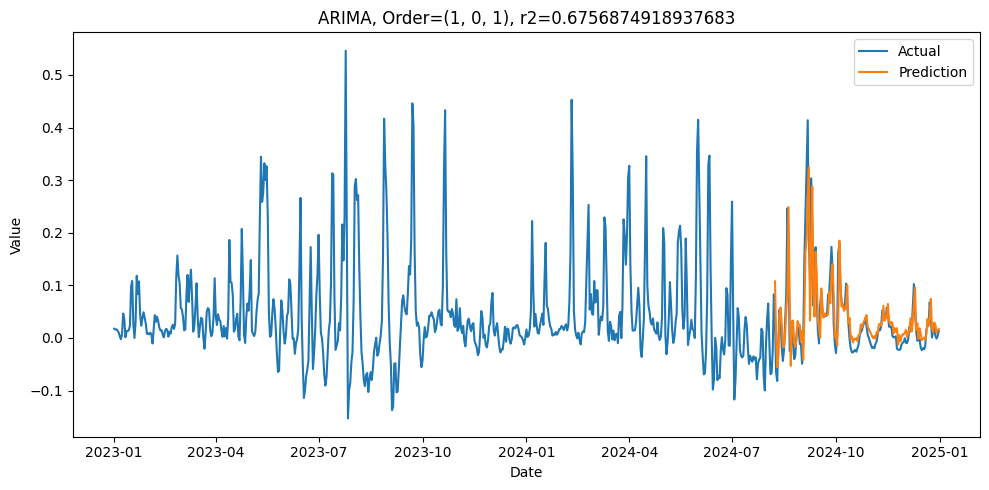

In [27]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

y = nearest_point_vo.values.flatten()

# -------------------------------------
# Train/test split
# -------------------------------------
test_size = int(len(y) * 0.2)
train = y[:-test_size]
test = y[-test_size:]

predictions = []

# rolling forecast
for i in range(test_size):
    train_data = y[: len(y) - test_size + i]   # expanding window
    model = ARIMA(train_data, order=(1, 0, 1))
    fitted = model.fit()
    pred = fitted.forecast()[0]
    predictions.append(pred)

# metrics
mae = mean_absolute_error(test, predictions)
r2 = r2_score(test, predictions)

# Table
results_table = pd.DataFrame({
    "Model": ["ARIMA"],
    "Order": ["(1, 0, 1)"],
    "MAE": [mae],
    "R2": [r2]
})

print("\nResults Table:")
print(results_table)

# index for predictions
pred_index = nearest_point_vo.index[-test_size:]

preds_ser = pd.Series(predictions, index=pred_index)

plt.figure(figsize=(10,5))
plt.plot(nearest_point_vo.index, nearest_point_vo.values, label="Actual")
plt.plot(preds_ser.index, preds_ser.values, label="Prediction")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"ARIMA, Order=(1, 0, 1), r2={r2}")
plt.legend()
plt.tight_layout()
plt.show()

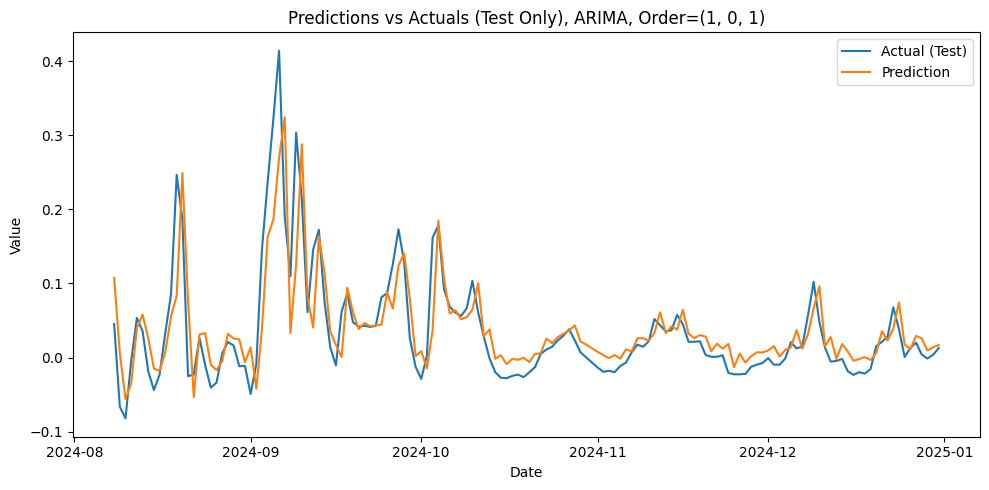

In [29]:
pred_index = nearest_point_vo.index[-test_size:]
preds_ser = pd.Series(predictions, index=pred_index)

plt.figure(figsize=(10,5))
plt.plot(pred_index, test, label="Actual (Test)")
plt.plot(preds_ser.index, preds_ser.values, label="Prediction")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Predictions vs Actuals (Test Only), ARIMA, Order=(1, 0, 1)")
plt.legend()
plt.tight_layout()
plt.show()


mae: 0.03108897991478443
r2: 0.5045298337936401


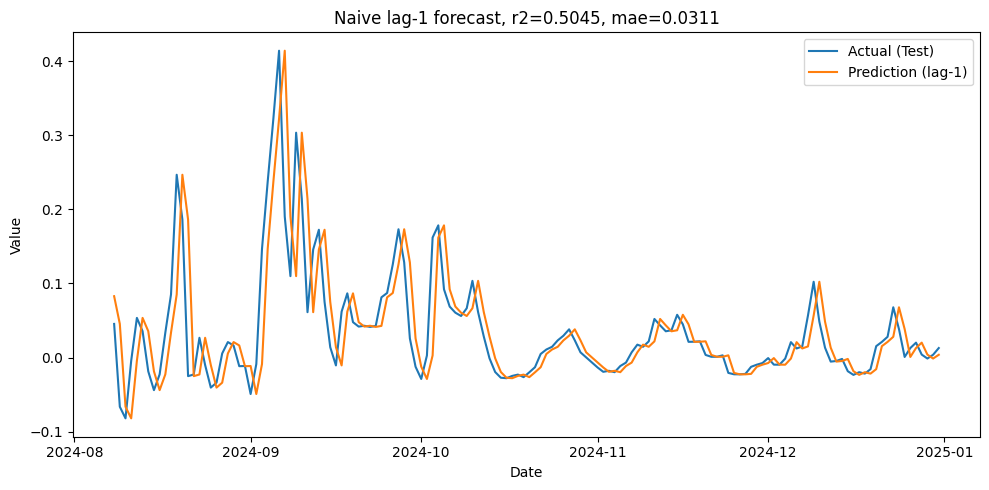

In [33]:
# assume y is a 1D numpy array and nearest_point_vo is the original Series
N = len(y)
T = test_size  # previously computed as int(len(y) * 0.2)

predictions = []
for i in range(T):
    # forecast time t = N - T + i
    # training data must include up to t-1 -> slice y[:t]
    t = N - T + i
    train_data = y[:t]           # includes indices [0 .. t-1]
    pred = train_data[-1]        # predict with the last observed value (lag-1)
    predictions.append(float(pred))

# true test values
test = y[-T:]

# metrics
mae = mean_absolute_error(test, predictions)
r2 = r2_score(test, predictions)
print("mae:", mae)
print("r2:", r2)

# series with correct index for plotting
pred_index = nearest_point_vo.index[-T:]
preds_ser = pd.Series(predictions, index=pred_index)

plt.figure(figsize=(10,5))
plt.plot(pred_index, test, label="Actual (Test)")
plt.plot(preds_ser.index, preds_ser.values, label="Prediction (lag-1)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"Naive lag-1 forecast, r2={r2:.4f}, mae={mae:.4f}")
plt.legend()
plt.tight_layout()
plt.show()



mae: 0.04490291699767113
r2: 0.1572282314300537


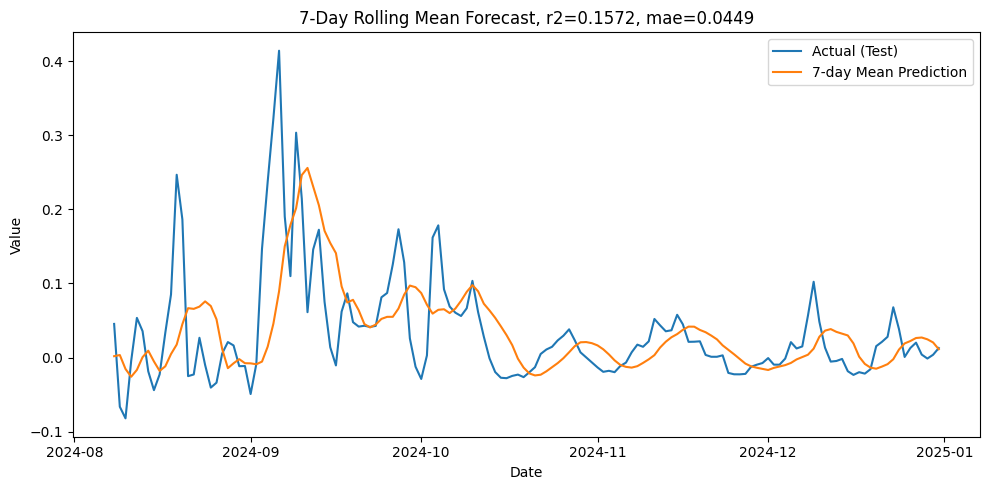

In [35]:
# 7-day mean forecast
predictions = []

N = len(y)
T = test_size  # last 20%
test = y[-T:]

for i in range(T):
    t = N - T + i            # current prediction time index
    train_data = y[:t]       # everything up to t-1
    pred = train_data[-7:].mean()   # mean of last 7 observations
    predictions.append(pred)

# metrics
mae = mean_absolute_error(test, predictions)
r2 = r2_score(test, predictions)
print("mae:", mae)
print("r2:", r2)

# match predictions to test dates
pred_index = nearest_point_vo.index[-T:]
preds_ser = pd.Series(predictions, index=pred_index)

# plot predictions vs actual
plt.figure(figsize=(10,5))
plt.plot(pred_index, test, label="Actual (Test)")
plt.plot(preds_ser.index, preds_ser.values, label="7-day Mean Prediction")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"7-Day Rolling Mean Forecast, r2={r2:.4f}, mae={mae:.4f}")
plt.legend()
plt.tight_layout()
plt.show()


## Final score

| Model        | Order   | MAE      | R2       |
| ------------ | ------- | -------- | -------- |
| Mean (1-day) | "-"     | 0.031089 | 0.504530 |
| Mean (7-day) | "-"     | 0.044903 | 0.157228 |
| ARIMA        | (1,0,1) | 0.027541 | 0.675687 |
| ARIMA        | (0,1,2) | 0.026926 | 0.655892 |
